# ML Pipeline
## Phase 1: Setup and Data Preperation
Load data, select right features for the model, ensure datas are in usable format. Handle Categorical Data. Scale the data

## Phase 2: Unsupervised Learning - Discovering Grip Strategies
Use the kinematic data to find natural groupings, which we will interpret as different "grip strategies". Do PCA, K Means Clustering Algorithm. Each Cluster will represent a grip strategy. Then assign cluster labels to the original DataFrame. Now every trial is assigned a grip strategy.
 
## Phase 3: Interpretation and Visualisation
Visualise the clusters. Use Cross tabulation to see how the discovered grip strategy relate to the experimental conditions (distance, surface). Eg. Strategy 0 is dominantly use for far distance and Strategy 1 is use for near distance.


## Phase 4: Supervised Learning
To build a machine learning model that can predict the experimental condition (like distance: near, middle, far) based solely on kinematic data (how the hand moved).

Goal: Predict which illusion the subject is viewing based only on their hand movements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

In [4]:
df_illusions = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/visual_illusions_master_dataset.csv")

print("Visual Illusions Dataset loaded successfully")
print(f"Dateset shape: {df_illusions.shape}")

Visual Illusions Dataset loaded successfully
Dateset shape: (1608, 170)


In [5]:
# 2. Feature Selection
identifier_cols = ['subjName', 'trialN']
condition_cols = ['visCond', 'illusion', 'targetPos', 'targetSize']

kinematic_features = df_illusions.select_dtypes(include=np.number).columns.tolist()
kinematic_features = [col for col in kinematic_features if col not in identifier_cols and col not in ['targetSize']]

print(f"\nIdentified {len(kinematic_features)} kinematic features.")

X_kinematic = df_illusions[kinematic_features].copy()

if X_kinematic.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the mean.")
    X_kinematic = X_kinematic.fillna(X_kinematic.mean())



Identified 164 kinematic features.


In [6]:
# 3. Scaling
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_kinematic)
print("Kinematic Features have been scaled")

Kinematic Features have been scaled


# Phase 2: Unsupervised Learning

In [7]:
# PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced dimensions to {pca.n_components_} components, explaining {np.sum(pca.explained_variance_ratio_):.2f}% of variance.")


PCA reduced dimensions to 50 components, explaining 0.95% of variance.


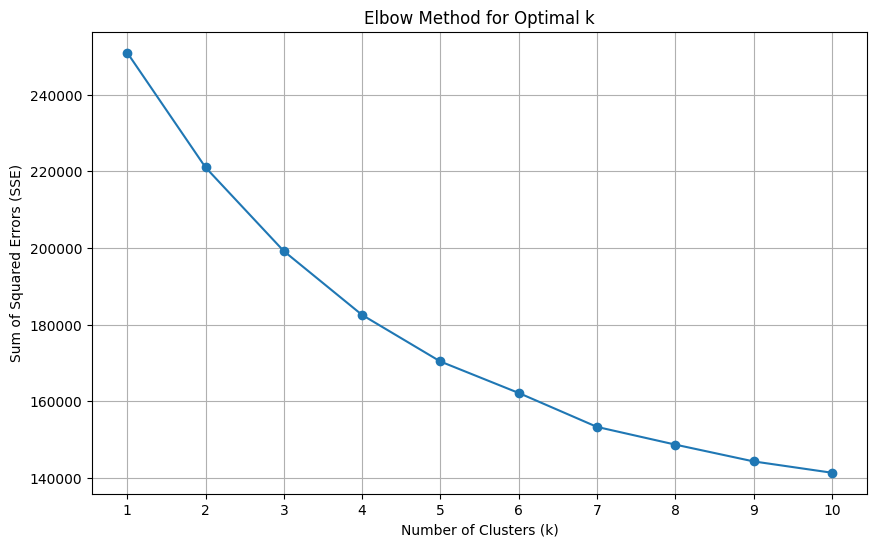

In [8]:
# Clusstering (K Means)
# FInd optimal number of k using Elbow Method
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
# 2. Clustering (K-Means)
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=123, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
df_illusions['movement_strategy'] = cluster_labels
print(f"Assigned trials to {optimal_k} movement strategies.")


Assigned trials to 4 movement strategies.


# Phase 3: Interpretation and Visualisation

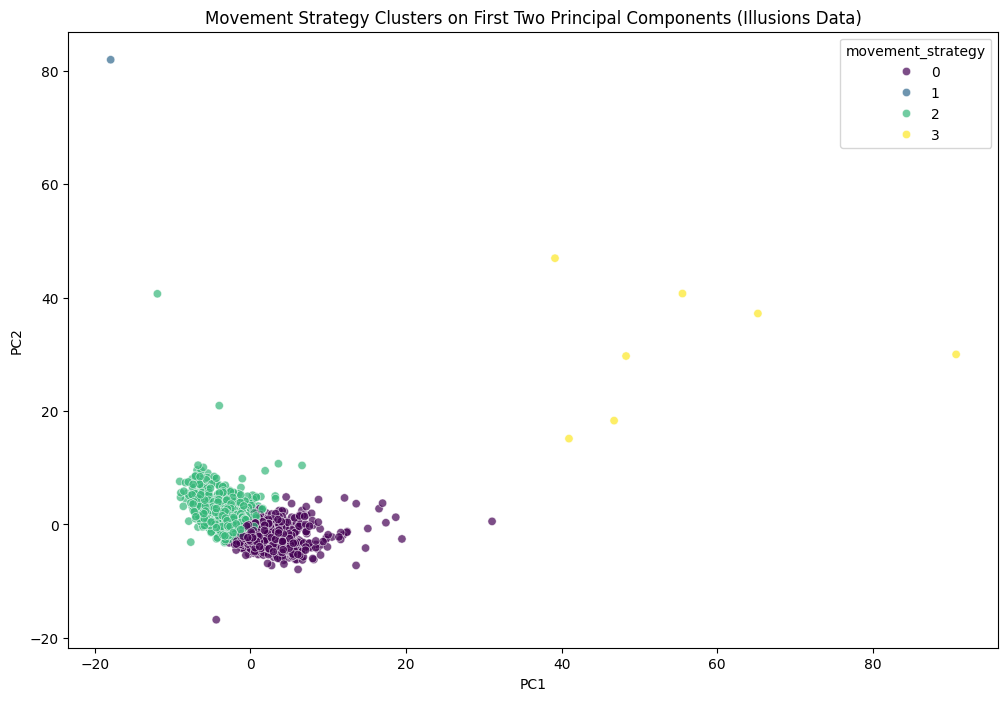

In [10]:
# 1. Visual Clusters
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['movement_strategy'] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='movement_strategy', data=pca_df, palette='viridis', alpha=0.7)
plt.title('Movement Strategy Clusters on First Two Principal Components (Illusions Data)')
plt.show()


The PCA plot is different from the others. We have two large, overlapping clusters (0 and 2) and two tiny, distant clusters (1 and 3).

In [11]:
# 2. Relate Strategies to Conditions
print("\nRelationship between movement strategies and 'illusion' type:")
print(pd.crosstab(df_illusions['movement_strategy'], df_illusions['illusion']))

print("\nRelationship between movement strategies and 'targetSize':")
print(pd.crosstab(df_illusions['movement_strategy'], df_illusions['targetSize']))



Relationship between movement strategies and 'illusion' type:
illusion           Ebbinghaus  Ponzo
movement_strategy                   
0                         443    397
1                           0      1
2                         363    397
3                           2      5

Relationship between movement strategies and 'targetSize':
targetSize          30   35   40
movement_strategy               
0                  301  269  270
1                    1    0    0
2                  268  254  238
3                    3    3    1


Clusters 0 and 2 (The "Standard Movement"): These two clusters contain over 99% of the data. Crucially, they are distributed almost evenly across both the Ebbinghaus and Ponzo illusions, and also across all three targetSize conditions.

Clusters 1 and 3 (Outliers): These are clearly outlier clusters, containing only a handful of trials. They should be treated as anomalies.

Key Interpretation: Unsupervised clustering did not find distinct, large-scale movement strategies that correspond to the illusion type. This means subjects do not use a fundamentally different "Ponzo strategy" vs. an "Ebbinghaus strategy." Instead, they appear to use a single, stereotyped movement pattern for the task, regardless of the illusion presented. The separation between cluster 0 and 2 might represent minor variations in this standard strategy (e.g., slightly faster vs. slower), but not a categorical difference based on the illusion.


# Phase 4: Supervised Learning (Predicting the 'illusion' type)

In [12]:
X_supervised = df_illusions[kinematic_features]
y_supervised = df_illusions['illusion']

le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)

groups = df_illusions['subjName']
group_kfold = GroupKFold(n_splits=5) 
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

cv_scores = cross_val_score(pipeline, X_supervised, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores for predicting illusion type: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Cross-validation accuracy scores for predicting illusion type: [0.7962963  0.7345679  0.75541796 0.77955272 0.66049383]
Mean CV Accuracy: 0.7453 (+/- 0.0473)


A Mean CV Accuracy of 74.53%.

While the unsupervised model couldn't find grossly different strategies, this supervised model shows that there are subtle but consistent kinematic differences between the movements. This means that even though the overall strategy is the same, the brain makes tiny, predictable adjustments to the movement based on the illusion it's perceiving. 

C:\Users\bharg\AppData\Local\Temp\ipykernel_48180\59409657.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


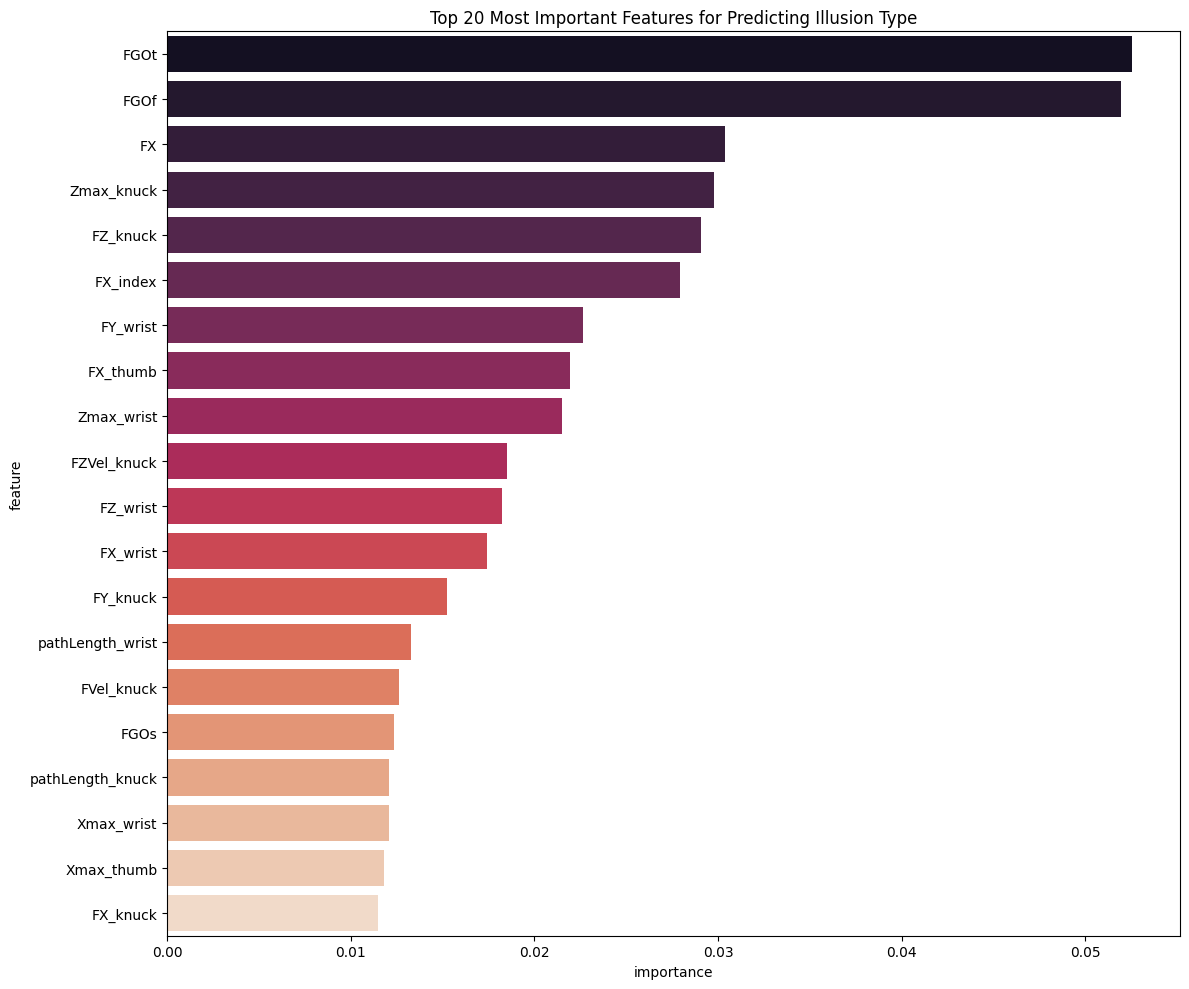

In [13]:
# 3. Feature Importance
pipeline.fit(X_supervised, y_encoded)
importances = pipeline.named_steps['rf'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': kinematic_features,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Most Important Features for Predicting Illusion Type')
plt.tight_layout()
plt.show()


Dominant Features: The top features are completely different from the distance-based tasks. Here, the winners are FGOt (Finger-Object Opening Time), FGOf (Finger-Object Final/Force), and FX (Final X position).

Interpretation: The model is telling us that the illusion's main effect isn't on the big "reaching" part of the movement. Instead, it's on the final, delicate, temporal aspects of the grasp itself.
FGOt (Time) being #1 suggests that the timing of when the fingers open relative to the object is the most critical variable affected by the illusion.

The importance of FX, FY, and other final position/force markers (FGOf, FGOs) shows that the illusion subtly alters the final configuration of the hand and fingers just before contact.

The illusion tricks the brain about the object's size, so the brain makes tiny miscalculations in the final moments of shaping the hand to grasp it.


Grasping vs. Aiming for Distance: We have demonstrated that for goal-directed tasks varying by distance, humans employ a small number of distinct, classifiable strategies (e.g., "Short-Range Point," "Long-Range Lunge"). Across both tasks, the primary kinematic correlate of intended distance is the maximum forward displacement (Z-axis) of the hand and fingers.

The Subtle Influence of Illusions: We have shown that visual illusions do not cause a wholesale change in motor strategy. However, they introduce subtle, systematic modulations to the kinematics. These changes are too small to be discovered as separate clusters but are strong enough to allow a machine learning model to predict which illusion a subject was viewing with ~75% accuracy.

A Tale of Two Motor Plans: The feature importance plots tell a compelling story.
To plan for distance, the brain primarily modulates the amplitude and power of the transport phase (the reach), evidenced by the importance of Zmax and FZVel.
To plan for grasping an illusory object, the brain makes adjustments to the timing and configuration of the grasp-shaping phase, evidenced by the importance of FGOt and final finger positions.